In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Total number of emigrants from Romania by counties 1990 - 2024

In [2]:
# Read the CSV file 'exportPivot_POP309A.csv' from the 'ins_files' folder,
# using comma as delimiter, and manually assign column names;
# skip the first row (which contains the original header)
table1 = pd.read_csv('ins_files/exportPivot_POP309A.csv', delimiter = ',', names = ['sex','county', 'years', 'nr_pers','emigrants'], skiprows = 1)

# Create an independent copy of table1 and store it in a new DataFrame
df_emigrants_1990_2024 = table1.copy()

# Display the DataFrame
df_emigrants_1990_2024

,sex,county,years,nr_pers,emigrants
0,Total,Bihor,Year 1990,Number of persons,3011
1,Total,Bihor,Year 1991,Number of persons,1789
2,Total,Bihor,Year 1992,Number of persons,1646
3,Total,Bihor,Year 1993,Number of persons,793
4,Total,Bihor,Year 1994,Number of persons,552
...,...,...,...,...,...
1465,Total,Timis,Year 2020,Number of persons,1078
1466,Total,Timis,Year 2021,Number of persons,1677
1467,Total,Timis,Year 2022,Number of persons,2309
1468,Total,Timis,Year 2023,Number of persons,1989


In [ ]:
# Drop the columns 'nr_pers' and 'sex' from the DataFrame (axis=1 means columns)
df_emigrants_1990_2024 = df_emigrants_1990_2024.drop(['nr_pers', 'sex'], axis = 1)
df_emigrants_1990_2024

,county,years,emigrants
0,Bihor,Year 1990,3011
1,Bihor,Year 1991,1789
2,Bihor,Year 1992,1646
3,Bihor,Year 1993,793
4,Bihor,Year 1994,552
...,...,...,...
1465,Timis,Year 2020,1078
1466,Timis,Year 2021,1677
1467,Timis,Year 2022,2309
1468,Timis,Year 2023,1989


In [ ]:
# Remove the string 'Year ' from the beginning/end of each value in the 'years' column
df_emigrants_1990_2024['years'] = df_emigrants_1990_2024['years'].str.strip('Year ')
df_emigrants_1990_2024

,county,years,emigrants
0,Bihor,1990,3011
1,Bihor,1991,1789
2,Bihor,1992,1646
3,Bihor,1993,793
4,Bihor,1994,552
...,...,...,...
1465,Timis,2020,1078
1466,Timis,2021,1677
1467,Timis,2022,2309
1468,Timis,2023,1989


In [ ]:
# Pivot the DataFrame so that 'county' becomes the index,
# 'years' values become the columns, and 'emigrants' values fill the cells
df_emigrants_1990_2024 = df_emigrants_1990_2024.pivot(index='county',columns='years',values='emigrants')

# Display the first 5 rows of the pivoted DataFrame
df_emigrants_1990_2024.head()

years,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
county,,,,,,,,,,,,,,,,,,,,,
Alba,2773,1197,625,545,272,466,330,309,184,158,...,193,288,314,396,374,267,444,573,513,379
Arad,7335,2808,1422,2226,820,1076,860,971,501,357,...,378,561,552,590,558,557,788,1122,937,766
Arges,270,321,116,94,140,313,251,262,222,185,...,250,367,360,406,436,348,491,700,607,442
Bacau,232,240,200,116,151,239,262,294,269,264,...,592,856,880,1062,1172,782,1383,2266,2365,2695
Bihor,3011,1789,1646,793,552,1018,658,734,466,289,...,226,369,305,421,392,282,532,681,616,520


In [ ]:
# Reset the index of the DataFrame, converting 'county' back into a regular column
df_emigrants_1990_2024 = df_emigrants_1990_2024.reset_index()

In [ ]:
# Remove the name of the columns axis (eliminates the label 'years' displayed above the column headers)
df_emigrants_1990_2024.columns.name = None

In [ ]:
# Display the first 5 rows of the DataFrame
df_emigrants_1990_2024.head()

,county,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Alba,2773,1197,625,545,272,466,330,309,184,...,193,288,314,396,374,267,444,573,513,379
1,Arad,7335,2808,1422,2226,820,1076,860,971,501,...,378,561,552,590,558,557,788,1122,937,766
2,Arges,270,321,116,94,140,313,251,262,222,...,250,367,360,406,436,348,491,700,607,442
3,Bacau,232,240,200,116,151,239,262,294,269,...,592,856,880,1062,1172,782,1383,2266,2365,2695
4,Bihor,3011,1789,1646,793,552,1018,658,734,466,...,226,369,305,421,392,282,532,681,616,520


In [10]:
df_emigrants_1990_2024 = df_emigrants_1990_2024.copy()

In [ ]:
# Export the DataFrame to an Excel file named 'emigrants_1990_2024.xlsx',
# without including the row index in the output file
df_emigrants_1990_2024.to_excel('emigrants_1990_2024.xlsx', index = False)

### Number of emigrants from Romania by counties 2012-2024

In [ ]:
# Build a list of columns that includes 'county' first, followed by all columns whose year value is greater than or equal to 2012
cols = ['county'] + [col for col in df_emigrants_1990_2024.columns if col != 'county' and int(col) >= 2012]

# Filter the DataFrame to keep only the selected columns
df_emigrants_1990_2024 = df_emigrants_1990_2024[cols]

# Display the updated DataFrame
df_emigrants_1990_2024

,county,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Alba,287,262,161,193,288,314,396,374,267,444,573,513,379
1,Arad,461,373,286,378,561,552,590,558,557,788,1122,937,766
2,Arges,214,208,175,250,367,360,406,436,348,491,700,607,442
3,Bacau,438,479,434,592,856,880,1062,1172,782,1383,2266,2365,2695
4,Bihor,263,259,176,226,369,305,421,392,282,532,681,616,520
5,Bistrita-Nasaud,334,321,219,267,385,362,442,369,281,453,579,528,487
6,Botosani,239,270,186,277,378,385,432,474,366,638,1030,1110,1514
7,Braila,211,218,167,210,334,370,420,401,344,498,642,576,428
8,Brasov,474,550,421,641,934,1000,1126,1030,722,1135,1622,1452,1238
9,Bucharest Municipality,5422,6043,1664,2531,3634,3783,4244,4092,3260,5305,7219,7108,8611


In [ ]:
# Create a new list of column names by adding the prefix 'E_' to each existing column name
new_columns = ['E_' + x  for x in df_emigrants_1990_2024.columns]

# Replace the first element (which would be 'E_county') back to 'county'
new_columns[0] = 'county'

# Assign the new column names to the DataFrame
df_emigrants_1990_2024.columns = new_columns

# Display the updated DataFrame
df_emigrants_1990_2024.head()

,county,E_2012,E_2013,E_2014,E_2015,E_2016,E_2017,E_2018,E_2019,E_2020,E_2021,E_2022,E_2023,E_2024
0,Alba,287,262,161,193,288,314,396,374,267,444,573,513,379
1,Arad,461,373,286,378,561,552,590,558,557,788,1122,937,766
2,Arges,214,208,175,250,367,360,406,436,348,491,700,607,442
3,Bacau,438,479,434,592,856,880,1062,1172,782,1383,2266,2365,2695
4,Bihor,263,259,176,226,369,305,421,392,282,532,681,616,520



### Romania's population by counties 2012 - 2024

In [ ]:
# Read the CSV file 'exportPivot_POP105A.csv' from the 'ins_files' folder,
# using comma as delimiter, and manually assign column names;
# skip the first row (which contains the original header)
table2 = pd.read_csv('ins_files/exportPivot_POP105A.csv', delimiter = ',', names = ['age','sex', 'areas', 'county','years', 'nr_pers','population'], skiprows = 1)

# Create an independent copy of table2 and store it in a new DataFrame
df_pop_2012_2024 = table2.copy()

# Display the DataFrame
table2

,age,sex,areas,county,years,nr_pers,population
0,Total,Total,Total,Bihor,Year 2012,Number of persons,575731
1,Total,Total,Total,Bihor,Year 2013,Number of persons,575270
2,Total,Total,Total,Bihor,Year 2014,Number of persons,573769
3,Total,Total,Total,Bihor,Year 2015,Number of persons,572057
4,Total,Total,Total,Bihor,Year 2016,Number of persons,568969
...,...,...,...,...,...,...,...
583,Total,Total,Total,Timis,Year 2021,Number of persons,706497
584,Total,Total,Total,Timis,Year 2022,Number of persons,652238
585,Total,Total,Total,Timis,Year 2023,Number of persons,658515
586,Total,Total,Total,Timis,Year 2024,Number of persons,663543


In [ ]:
# Drop the columns 'age', 'sex', 'areas' and 'nr_pers' from the DataFrame (axis=1 means columns)
df_pop_2012_2024 = df_pop_2012_2024.drop(['age', 'sex', 'areas', 'nr_pers'], axis = 1)

# Display the updated DataFrame
df_pop_2012_2024

,county,years,population
0,Bihor,Year 2012,575731
1,Bihor,Year 2013,575270
2,Bihor,Year 2014,573769
3,Bihor,Year 2015,572057
4,Bihor,Year 2016,568969
...,...,...,...
583,Timis,Year 2021,706497
584,Timis,Year 2022,652238
585,Timis,Year 2023,658515
586,Timis,Year 2024,663543


In [ ]:
# Remove the string 'Year ' from the left side of each value in the 'years' column
df_pop_2012_2024['years'] = df_pop_2012_2024['years'].str.lstrip('Year ')

# Display the updated DataFrame
df_pop_2012_2024

,county,years,population
0,Bihor,2012,575731
1,Bihor,2013,575270
2,Bihor,2014,573769
3,Bihor,2015,572057
4,Bihor,2016,568969
...,...,...,...
583,Timis,2021,706497
584,Timis,2022,652238
585,Timis,2023,658515
586,Timis,2024,663543


In [ ]:
# Pivot the DataFrame so that 'county' becomes the index,
# 'years' values become the columns, and 'population' values fill the cells
df_pop_2012_2024 = pd.pivot(df_pop_2012_2024, values = 'population', index = 'county', columns = 'years')

df_pop_2012_2024.head()

years,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
county,,,,,,,,,,,,,,
Alba,341479,339517,337717,335915,333488,330954,328264,325475,324071,321199,325715,325838,325697,325260
Arad,430683,429625,428079,426517,424075,421954,419135,417274,415914,413035,410282,410451,410871,410320
Arges,611024,606789,604153,600301,595764,590522,585713,579904,575197,567851,566913,565747,564829,561990
Bacau,614316,609948,606975,604567,600549,595534,591053,585548,582495,576683,599435,597504,595888,591999
Bihor,575731,575270,573769,572057,568969,566381,564171,561621,560646,557836,552031,554016,555957,556894


In [ ]:
# Reset the index of the DataFrame, converting 'county' back into a regular column
df_pop_2012_2024 = df_pop_2012_2024.reset_index()

In [19]:
# Drop the column '2025' from the DataFrame (axis=1 means columns)
df_pop_2012_2024 = df_pop_2012_2024.drop('2025', axis = 1)

df_pop_2012_2024.head()

years,county,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Alba,341479,339517,337717,335915,333488,330954,328264,325475,324071,321199,325715,325838,325697
1,Arad,430683,429625,428079,426517,424075,421954,419135,417274,415914,413035,410282,410451,410871
2,Arges,611024,606789,604153,600301,595764,590522,585713,579904,575197,567851,566913,565747,564829
3,Bacau,614316,609948,606975,604567,600549,595534,591053,585548,582495,576683,599435,597504,595888
4,Bihor,575731,575270,573769,572057,568969,566381,564171,561621,560646,557836,552031,554016,555957


In [20]:
# Remove the name of the columns axis (eliminates the label 'years' displayed above the column headers)
df_pop_2012_2024.columns.name = None

df_pop_2012_2024.head()

,county,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Alba,341479,339517,337717,335915,333488,330954,328264,325475,324071,321199,325715,325838,325697
1,Arad,430683,429625,428079,426517,424075,421954,419135,417274,415914,413035,410282,410451,410871
2,Arges,611024,606789,604153,600301,595764,590522,585713,579904,575197,567851,566913,565747,564829
3,Bacau,614316,609948,606975,604567,600549,595534,591053,585548,582495,576683,599435,597504,595888
4,Bihor,575731,575270,573769,572057,568969,566381,564171,561621,560646,557836,552031,554016,555957


In [21]:
# Create a new list of column names by adding the prefix 'P_' to each existing column name
new_columns = ['P_' + x  for x in df_pop_2012_2024.columns]

# Replace the first element (which would be 'P_county') back to 'county'
new_columns[0] = 'county'

# Assign the new column names to the DataFrame
df_pop_2012_2024.columns = new_columns

### Permanent emigration rate from Romania by region 2012 - 2024

In [22]:
df_pop_2012_2024.head()

,county,P_2012,P_2013,P_2014,P_2015,P_2016,P_2017,P_2018,P_2019,P_2020,P_2021,P_2022,P_2023,P_2024
0,Alba,341479,339517,337717,335915,333488,330954,328264,325475,324071,321199,325715,325838,325697
1,Arad,430683,429625,428079,426517,424075,421954,419135,417274,415914,413035,410282,410451,410871
2,Arges,611024,606789,604153,600301,595764,590522,585713,579904,575197,567851,566913,565747,564829
3,Bacau,614316,609948,606975,604567,600549,595534,591053,585548,582495,576683,599435,597504,595888
4,Bihor,575731,575270,573769,572057,568969,566381,564171,561621,560646,557836,552031,554016,555957


In [23]:
df_emigrants_1990_2024.head()

,county,E_2012,E_2013,E_2014,E_2015,E_2016,E_2017,E_2018,E_2019,E_2020,E_2021,E_2022,E_2023,E_2024
0,Alba,287,262,161,193,288,314,396,374,267,444,573,513,379
1,Arad,461,373,286,378,561,552,590,558,557,788,1122,937,766
2,Arges,214,208,175,250,367,360,406,436,348,491,700,607,442
3,Bacau,438,479,434,592,856,880,1062,1172,782,1383,2266,2365,2695
4,Bihor,263,259,176,226,369,305,421,392,282,532,681,616,520


In [24]:
# Merge the two DataFrames (df_emigrants_1990_2024 and df_pop_2012_2024) on the 'county' column,
# keeping only the rows that have matching values in both DataFrames (inner join)
df_emigration_pop_2012_2024 = pd.merge(df_emigrants_1990_2024, df_pop_2012_2024, on = 'county', how = 'inner')

df_emigration_pop_2012_2024

,county,E_2012,E_2013,E_2014,E_2015,E_2016,E_2017,E_2018,E_2019,E_2020,...,P_2015,P_2016,P_2017,P_2018,P_2019,P_2020,P_2021,P_2022,P_2023,P_2024
0,Alba,287,262,161,193,288,314,396,374,267,...,335915,333488,330954,328264,325475,324071,321199,325715,325838,325697
1,Arad,461,373,286,378,561,552,590,558,557,...,426517,424075,421954,419135,417274,415914,413035,410282,410451,410871
2,Arges,214,208,175,250,367,360,406,436,348,...,600301,595764,590522,585713,579904,575197,567851,566913,565747,564829
3,Bacau,438,479,434,592,856,880,1062,1172,782,...,604567,600549,595534,591053,585548,582495,576683,599435,597504,595888
4,Bihor,263,259,176,226,369,305,421,392,282,...,572057,568969,566381,564171,561621,560646,557836,552031,554016,555957
5,Bistrita-Nasaud,334,321,219,267,385,362,442,369,281,...,283255,282495,281387,280058,278868,278033,276517,295351,296140,297082
6,Botosani,239,270,186,277,378,385,432,474,366,...,399273,394625,390320,385268,380142,377679,373239,391108,389815,389748
7,Braila,211,218,167,210,334,370,420,401,344,...,308203,303608,299087,294097,289534,286021,280796,280196,277021,274751
8,Brasov,474,550,421,641,934,1000,1126,1030,722,...,551160,550934,550789,551185,552390,554014,553807,548254,552813,557129
9,Bucharest Municipality,5422,6043,1664,2531,3634,3783,4244,4092,3260,...,1853638,1843962,1826579,1828869,1832802,1841052,1828781,1722974,1724966,1721784


In [ ]:
# Calculate the emigration rate per 1000 inhabitants by dividing the emigrants columns (columns 1-13)
# by the population columns (columns 14 onwards) and multiplying by 1000
emigration_rate_county_2012_2024 = df_emigration_pop_2012_2024.iloc[:, 1:14].values / df_emigration_pop_2012_2024.iloc[:,14:].values * 1000

# Convert the result into a DataFrame and assign column names by stripping the 'E_' prefix from the emigrants columns
emigration_rate_county_2012_2024= pd.DataFrame(emigration_rate_county_2012_2024, columns = df_emigration_pop_2012_2024.columns[1:14].str.lstrip('E_'))

# Insert the 'county' column at the first position (index 0) of the DataFrame
emigration_rate_county_2012_2024.insert(0, 'county', df_emigration_pop_2012_2024['county'].values)


# Display the updated DataFrame
emigration_rate_county_2012_2024

,county,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Alba,0.840462,0.771684,0.476731,0.574550,0.863599,0.948772,1.206346,1.149090,0.823894,1.382321,1.759207,1.574402,1.163658
1,Arad,1.070393,0.868199,0.668101,0.886248,1.322879,1.308199,1.407661,1.337251,1.339219,1.907829,2.734704,2.282855,1.864332
2,Arges,0.350232,0.342788,0.289662,0.416458,0.616016,0.609630,0.693172,0.751849,0.605010,0.864663,1.234757,1.072918,0.782538
3,Bacau,0.712988,0.785313,0.715021,0.979213,1.425362,1.477665,1.796793,2.001544,1.342501,2.398198,3.780226,3.958132,4.522662
4,Bihor,0.456811,0.450223,0.306744,0.395066,0.648541,0.538507,0.746228,0.697980,0.502991,0.953685,1.233626,1.111881,0.935324
5,Bistrita-Nasaud,1.170009,1.129574,0.771371,0.942614,1.362856,1.286484,1.578245,1.323207,1.010671,1.638236,1.960379,1.782941,1.639278
6,Botosani,0.581925,0.664485,0.461304,0.693761,0.957871,0.986370,1.121297,1.246902,0.969077,1.709360,2.633544,2.847505,3.884561
7,Braila,0.660047,0.690752,0.534996,0.681369,1.100103,1.237098,1.428100,1.384984,1.202709,1.773530,2.291253,2.079265,1.557774
8,Brasov,0.862573,0.998705,0.764187,1.163002,1.695303,1.815577,2.042871,1.864625,1.303216,2.049450,2.958483,2.626566,2.222107
9,Bucharest Municipality,2.873548,3.222265,0.891956,1.365423,1.970756,2.071085,2.320560,2.232647,1.770727,2.900839,4.189848,4.120661,5.001208


In [26]:
# Remove any leading whitespace from the values in the first column ('county')
emigration_rate_county_2012_2024.iloc[:,0] = emigration_rate_county_2012_2024.iloc[:,0].str.lstrip()

In [49]:
# permanent emigration rate by counties 2012-2024
emigration_rate_county_2012_2024.to_excel('emigration_rate_county_2012_2024.xlsx', index = False, float_format="%.1f")

In [28]:
# Replace the non-breaking space character ('\xa0') with a regular space,
# then remove any leading and trailing whitespace from the 'county' column
df_emigration_pop_2012_2024['county'] = df_emigration_pop_2012_2024['county'].str.replace('\xa0', ' ').str.strip()

In [ ]:
# Add a new empty column called 'region' to the DataFrame
df_emigration_pop_2012_2024["region"] = ""

In [30]:
df_emigration_pop_2012_2024.head()

,county,E_2012,E_2013,E_2014,E_2015,E_2016,E_2017,E_2018,E_2019,E_2020,...,P_2016,P_2017,P_2018,P_2019,P_2020,P_2021,P_2022,P_2023,P_2024,region
0,Alba,287,262,161,193,288,314,396,374,267,...,333488,330954,328264,325475,324071,321199,325715,325838,325697,
1,Arad,461,373,286,378,561,552,590,558,557,...,424075,421954,419135,417274,415914,413035,410282,410451,410871,
2,Arges,214,208,175,250,367,360,406,436,348,...,595764,590522,585713,579904,575197,567851,566913,565747,564829,
3,Bacau,438,479,434,592,856,880,1062,1172,782,...,600549,595534,591053,585548,582495,576683,599435,597504,595888,
4,Bihor,263,259,176,226,369,305,421,392,282,...,568969,566381,564171,561621,560646,557836,552031,554016,555957,


In [31]:
# Define lists of counties grouped by their corresponding historical regions of Rom
counties_transilvania = ["Alba", "Arad", "Bihor", "Bistrita-Nasaud", "Brasov", 
                       "Cluj", "Covasna", "Harghita", "Hunedoara", "Maramures", 
                       "Mures", "Salaj", "Sibiu", "Satu Mare", 'Caras-Severin', 'Timis']

counties_oltenia = ["Dolj", "Gorj", "Mehedinti", "Olt", "Valcea"]

counties_muntenia_dobrogea = ["Arges", "Braila", "Buzau", "Calarasi", "Dambovita", 
                   "Giurgiu", "Ialomita", "Prahova", "Teleorman", 'Constanta', 'Tulcea']

counties_moldova = ["Bacau", "Botosani", "Galati", "Iasi", "Neamt", 
                  "Suceava", "Vaslui", "Vrancea"]

counties_bucharest_ilfov = ["Bucharest Municipality", "Ilfov"]

In [ ]:
# Assign a region name to each county using nested np.where conditions;
# each county is mapped to its corresponding historical region of Romania,
# based on the county lists defined earlier
df_emigration_pop_2012_2024["region"] = np.where(
    df_emigration_pop_2012_2024["county"].isin(counties_transilvania), "Transilvania",
    np.where(df_emigration_pop_2012_2024["county"].isin(counties_oltenia), "Oltenia",
    np.where(df_emigration_pop_2012_2024["county"].isin(counties_muntenia_dobrogea), "Muntenia-Dobrogea",
    np.where(df_emigration_pop_2012_2024["county"].isin(counties_moldova), "Moldova",
    np.where(df_emigration_pop_2012_2024["county"].isin(counties_bucharest_ilfov), "Bucharest-Ilfov",
             "")))))


# Display the updated DataFrame
df_emigration_pop_2012_2024

,county,E_2012,E_2013,E_2014,E_2015,E_2016,E_2017,E_2018,E_2019,E_2020,...,P_2016,P_2017,P_2018,P_2019,P_2020,P_2021,P_2022,P_2023,P_2024,region
0,Alba,287,262,161,193,288,314,396,374,267,...,333488,330954,328264,325475,324071,321199,325715,325838,325697,Transilvania
1,Arad,461,373,286,378,561,552,590,558,557,...,424075,421954,419135,417274,415914,413035,410282,410451,410871,Transilvania
2,Arges,214,208,175,250,367,360,406,436,348,...,595764,590522,585713,579904,575197,567851,566913,565747,564829,Muntenia-Dobrogea
3,Bacau,438,479,434,592,856,880,1062,1172,782,...,600549,595534,591053,585548,582495,576683,599435,597504,595888,Moldova
4,Bihor,263,259,176,226,369,305,421,392,282,...,568969,566381,564171,561621,560646,557836,552031,554016,555957,Transilvania
5,Bistrita-Nasaud,334,321,219,267,385,362,442,369,281,...,282495,281387,280058,278868,278033,276517,295351,296140,297082,Transilvania
6,Botosani,239,270,186,277,378,385,432,474,366,...,394625,390320,385268,380142,377679,373239,391108,389815,389748,Moldova
7,Braila,211,218,167,210,334,370,420,401,344,...,303608,299087,294097,289534,286021,280796,280196,277021,274751,Muntenia-Dobrogea
8,Brasov,474,550,421,641,934,1000,1126,1030,722,...,550934,550789,551185,552390,554014,553807,548254,552813,557129,Transilvania
9,Bucharest Municipality,5422,6043,1664,2531,3634,3783,4244,4092,3260,...,1843962,1826579,1828869,1832802,1841052,1828781,1722974,1724966,1721784,Bucharest-Ilfov


In [33]:
df_emigration_pop_2012_2024 = df_emigration_pop_2012_2024.copy()

In [34]:
# Export the DataFrame to an Excel file named 'emigration_pop_2012_2024.xlsx',
df_emigration_pop_2012_2024.to_excel('emigration_pop_2012_2024.xlsx', index = False)

In [35]:
# Group the DataFrame by 'region' and calculate the sum of all numeric columns for each region
df_emigration_pop_2012_2024.groupby(['region']).sum(numeric_only = True)

,E_2012,E_2013,E_2014,E_2015,E_2016,E_2017,E_2018,E_2019,E_2020,E_2021,...,P_2015,P_2016,P_2017,P_2018,P_2019,P_2020,P_2021,P_2022,P_2023,P_2024
region,,,,,,,,,,,,,,,,,,,,,
Bucharest-Ilfov,5479,6148,1797,2705,3848,4059,4549,4411,3538,5739,...,2284443,2288203,2287065,2302291,2318109,2327921,2332456,2268381,2289799,2305447
Moldova,3668,3424,2553,3478,5360,5602,6995,7470,6098,10419,...,4130769,4107729,4082927,4058034,4029657,4014174,3986773,4051093,4051862,4052136
Muntenia-Dobrogea,2393,2858,2106,2664,4176,4191,4946,4703,3671,5540,...,4695782,4650428,4607284,4553172,4502231,4463234,4413945,4387489,4367197,4353473
Oltenia,791,797,681,833,1363,1234,1470,1497,1114,1948,...,2015792,1993482,1972940,1949813,1927215,1911414,1892961,1869602,1861811,1855697
Transilvania,5670,5829,4114,5555,8060,8070,9269,8694,6610,10695,...,6748756,6720743,6693733,6670171,6648661,6637596,6603384,6466533,6484559,6500823


In [ ]:
# Group the DataFrame by 'region', calculate the sum of all numeric columns for each region,
# and store the result in a new DataFrame
df_region_emigration_pop_2012_2024 = df_emigration_pop_2012_2024.groupby(['region']).sum(numeric_only = True)


# Reset the index of the DataFrame, converting 'region' back into a regular column
df_region_emigration_pop_2012_2024 = df_region_emigration_pop_2012_2024.reset_index()

# Display the updated DataFrame
df_region_emigration_pop_2012_2024

,region,E_2012,E_2013,E_2014,E_2015,E_2016,E_2017,E_2018,E_2019,E_2020,...,P_2015,P_2016,P_2017,P_2018,P_2019,P_2020,P_2021,P_2022,P_2023,P_2024
0,Bucharest-Ilfov,5479,6148,1797,2705,3848,4059,4549,4411,3538,...,2284443,2288203,2287065,2302291,2318109,2327921,2332456,2268381,2289799,2305447
1,Moldova,3668,3424,2553,3478,5360,5602,6995,7470,6098,...,4130769,4107729,4082927,4058034,4029657,4014174,3986773,4051093,4051862,4052136
2,Muntenia-Dobrogea,2393,2858,2106,2664,4176,4191,4946,4703,3671,...,4695782,4650428,4607284,4553172,4502231,4463234,4413945,4387489,4367197,4353473
3,Oltenia,791,797,681,833,1363,1234,1470,1497,1114,...,2015792,1993482,1972940,1949813,1927215,1911414,1892961,1869602,1861811,1855697
4,Transilvania,5670,5829,4114,5555,8060,8070,9269,8694,6610,...,6748756,6720743,6693733,6670171,6648661,6637596,6603384,6466533,6484559,6500823


In [ ]:
# Display the column names of the DataFrame
df_region_emigration_pop_2012_2024.columns

Index(['region', 'E_2012', 'E_2013', 'E_2014', 'E_2015', 'E_2016', 'E_2017',
       'E_2018', 'E_2019', 'E_2020', 'E_2021', 'E_2022', 'E_2023', 'E_2024',
       'P_2012', 'P_2013', 'P_2014', 'P_2015', 'P_2016', 'P_2017', 'P_2018',
       'P_2019', 'P_2020', 'P_2021', 'P_2022', 'P_2023', 'P_2024'],
      dtype='str')

In [ ]:
# Calculate the emigration rate per 1000 inhabitants by dividing the emigrants columns (columns 1-13)
# by the population columns (columns 14-26) and multiplying by 1000
emigration_rate_region_2012_2024 = df_region_emigration_pop_2012_2024.iloc[:, 1:14].values / df_region_emigration_pop_2012_2024.iloc[:, 14:27].values * 1000

# Convert the result into a DataFrame and assign column names by stripping the 'E_' prefix from the emigrants columns
emigration_rate_region_2012_2024 = pd.DataFrame(
    emigration_rate_region_2012_2024,
    columns = df_region_emigration_pop_2012_2024.columns[1:14].str.lstrip('E_')
)

# Insert the 'region' column at the first position (index 0) of the DataFrame
emigration_rate_region_2012_2024.insert(0, "region", df_region_emigration_pop_2012_2024["region"].values)

In [ ]:
# Display the updated DataFrame
emigration_rate_region_2012_2024

,region,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Bucharest-Ilfov,2.403972,2.693840,0.786980,1.184096,1.681669,1.774764,1.975858,1.902844,1.519811,2.460497,3.442543,3.377589,3.987513
1,Moldova,0.879958,0.825660,0.616759,0.841974,1.304857,1.372055,1.723741,1.853756,1.519117,2.613392,4.049278,4.675381,6.084939
2,Muntenia-Dobrogea,0.499211,0.600002,0.445095,0.567318,0.897982,0.909647,1.086276,1.044593,0.822498,1.255113,1.692312,1.548133,1.201340
3,Oltenia,0.382614,0.389027,0.334844,0.413237,0.683728,0.625463,0.753918,0.776769,0.582815,1.029076,1.346811,1.255229,0.989386
4,Transilvania,0.835354,0.859883,0.608135,0.823115,1.199272,1.205605,1.389620,1.307632,0.995842,1.619624,2.208602,1.979472,1.560725


In [ ]:
# Export the DataFrame to an Excel file named 'emigration_rate_region_2012_2024.xlsx',
# without including the row index, and rounding all float values to 1 decimal place
emigration_rate_region_2012_2024.to_excel('emigration_rate_region_2012_2024.xlsx', index = False, float_format="%.1f")

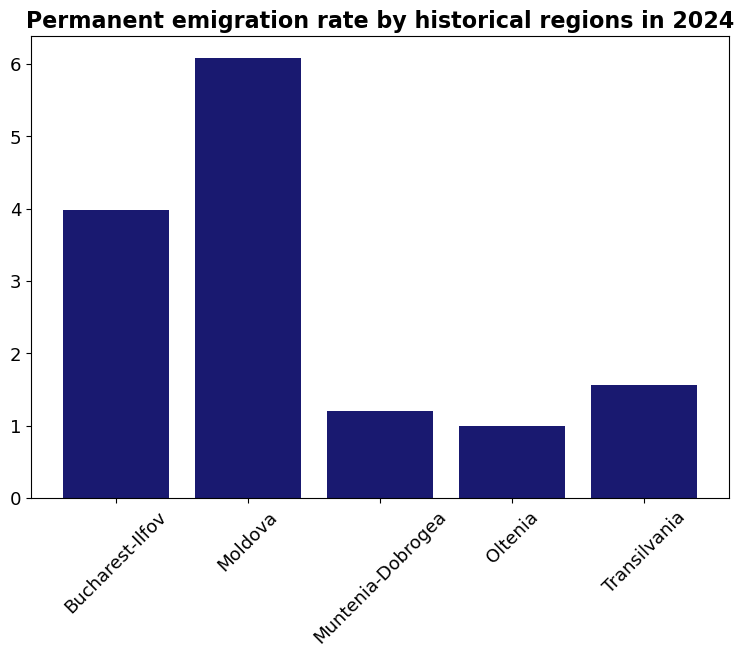

In [54]:
# Create a new figure with a width of 9 inches and a height of 6 inches
plt.figure(figsize = (9, 6))

# Draw a bar chart with regions on the x-axis and their 2024 emigration rate on the y-axis,
# using midnight blue as the bar color
plt.bar( x = emigration_rate_region_2012_2024['region'], height = emigration_rate_region_2012_2024['2024'], color = 'midnightblue')

# Rotate the x-axis labels by 45 degrees and set their font size to 13
plt.xticks(rotation = 45, fontsize = 13) 

# Set the font size of the y-axis tick labels to 13
plt.yticks(fontsize = 13)

# Add a bold title to the chart with a font size of 16
plt.title("Permanent emigration rate by historical regions in 2024", fontsize = 16, fontweight = "bold")

# Display the chart
plt.show()


### Number of permanent emigrants from Romania by counties 1990 - 2011

In [55]:
# Read the first 23 columns (columns 0-22) from the Excel file 'emigrants_1990_2024.xlsx'
# and store the result in table1
table1 = pd.read_excel('emigrants_1990_2024.xlsx', usecols = range(23))

df_emigrants_1990_2011 = table1.copy()

df_emigrants_1990_2011.head()

,county,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
0,Alba,2773,1197,625,545,272,466,330,309,184,...,86,168,189,146,239,142,153,155,105,241
1,Arad,7335,2808,1422,2226,820,1076,860,971,501,...,240,264,345,249,330,200,226,251,206,366
2,Arges,270,321,116,94,140,313,251,262,222,...,99,79,99,85,117,97,112,148,141,194
3,Bacau,232,240,200,116,151,239,262,294,269,...,196,355,457,479,654,333,320,369,293,415
4,Bihor,3011,1789,1646,793,552,1018,658,734,466,...,334,425,521,297,335,178,181,219,143,281


In [ ]:
# Create a new list of column names by adding the prefix 'E_' to each existing column name
new_columns = ['E_' + x for x in df_emigrants_1990_2011.columns]

# Replace the first element (which would be 'E_county') back to 'county'
new_columns[0] = 'county'

# Assign the new column names to the DataFrame
df_emigrants_1990_2011.columns = new_columns

df_emigrants_1990_2011.head()

,county,E_1990,E_1991,E_1992,E_1993,E_1994,E_1995,E_1996,E_1997,E_1998,...,E_2002,E_2003,E_2004,E_2005,E_2006,E_2007,E_2008,E_2009,E_2010,E_2011
0,Alba,2773,1197,625,545,272,466,330,309,184,...,86,168,189,146,239,142,153,155,105,241
1,Arad,7335,2808,1422,2226,820,1076,860,971,501,...,240,264,345,249,330,200,226,251,206,366
2,Arges,270,321,116,94,140,313,251,262,222,...,99,79,99,85,117,97,112,148,141,194
3,Bacau,232,240,200,116,151,239,262,294,269,...,196,355,457,479,654,333,320,369,293,415
4,Bihor,3011,1789,1646,793,552,1018,658,734,466,...,334,425,521,297,335,178,181,219,143,281


In [57]:
# Remove any leading whitespace from the values in the 'county' column
df_emigrants_1990_2011['county'] = df_emigrants_1990_2011['county'].str.lstrip()

### Population from Romania by county 1990 - 2011

In [ ]:
# Read the CSV file 'exportPivot_POP107A.csv' from the 'ins_files' folder,
# using comma as delimiter, and manually assign column names;
# skip the first row (which contains the original header)
table_2 = pd.read_csv('ins_files/exportPivot_POP107A.csv', delimiter = ',', names = ['age','sex', 'areas', 'county', 'years', 'nr_pers','population'], skiprows = 1)

df_pop_1992_2011 = table_2.copy()

# Display the DataFrame
df_pop_1992_2011

,age,sex,areas,county,years,nr_pers,population
0,Total,Total,Total,Bihor,Year 1992,Number of persons,654414
1,Total,Total,Total,Bihor,Year 1993,Number of persons,651663
2,Total,Total,Total,Bihor,Year 1994,Number of persons,649284
3,Total,Total,Total,Bihor,Year 1995,Number of persons,647687
4,Total,Total,Total,Bihor,Year 1996,Number of persons,644811
...,...,...,...,...,...,...,...
835,Total,Total,Total,Timis,Year 2007,Number of persons,716420
836,Total,Total,Total,Timis,Year 2008,Number of persons,720785
837,Total,Total,Total,Timis,Year 2009,Number of persons,724277
838,Total,Total,Total,Timis,Year 2010,Number of persons,727041


In [ ]:
# Drop the columns 'age', 'sex', 'areas' and 'nr_pers' from the DataFrame (axis=1 means columns)
df_pop_1992_2011 = df_pop_1992_2011.drop(['age', 'sex', 'areas', 'nr_pers'], axis = 1)

# Display the updated DataFrame
df_pop_1992_2011

,county,years,population
0,Bihor,Year 1992,654414
1,Bihor,Year 1993,651663
2,Bihor,Year 1994,649284
3,Bihor,Year 1995,647687
4,Bihor,Year 1996,644811
...,...,...,...
835,Timis,Year 2007,716420
836,Timis,Year 2008,720785
837,Timis,Year 2009,724277
838,Timis,Year 2010,727041


In [ ]:
# Remove the string 'Year ' from the left side of each value in the 'years' column
df_pop_1992_2011['years'] = df_pop_1992_2011['years'].str.lstrip('Year ')

# Display the updated DataFrame
df_pop_1992_2011

,county,years,population
0,Bihor,1992,654414
1,Bihor,1993,651663
2,Bihor,1994,649284
3,Bihor,1995,647687
4,Bihor,1996,644811
...,...,...,...
835,Timis,2007,716420
836,Timis,2008,720785
837,Timis,2009,724277
838,Timis,2010,727041


In [ ]:
# Pivot the DataFrame so that 'county' becomes the index,
# 'years' values become the columns, and 'population' values fill the cells
df_pop_1992_2011 = pd.pivot(df_pop_1992_2011, values = 'population', index = 'county', columns = 'years')

df_pop_1992_2011.head()

years,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
county,,,,,,,,,,,,,,,,,,,,
Alba,419698,417700,415728,414091,411998,409942,408257,406478,404806,403466,402290,400760,399162,397650,396429,394641,393390,391990,390612,388869
Arad,491675,491152,489045,487669,486539,484743,484194,484410,484423,484884,484444,483708,483456,482919,481807,481419,481638,481765,480805,480473
Arges,680670,681456,682034,682033,680729,679127,677710,676390,675583,674530,672538,670067,668567,666747,665394,664403,665041,664279,662359,660054
Bacau,751282,752136,752914,754046,754909,754692,755824,757733,759162,761137,762289,762369,761723,761732,761451,760651,760013,759080,757825,754964
Bihor,654414,651663,649284,647687,644811,641904,639185,637914,636374,635161,632847,631056,629155,627257,626219,625647,625611,625286,624809,624695


In [ ]:
# Remove the name of the columns axis (eliminates the label 'years' displayed above the column headers)
df_pop_1992_2011.columns.name = None

# Reset the index of the DataFrame, converting 'county' back into a regular column
df_pop_1992_2011 = df_pop_1992_2011.reset_index()

In [ ]:
# Remove any leading and trailing whitespace from the values in the 'county' column
df_pop_1992_2011['county'] = df_pop_1992_2011['county'].str.strip()

df_pop_1992_2011.head()

,county,1992,1993,1994,1995,1996,1997,1998,1999,2000,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
0,Alba,419698,417700,415728,414091,411998,409942,408257,406478,404806,...,402290,400760,399162,397650,396429,394641,393390,391990,390612,388869
1,Arad,491675,491152,489045,487669,486539,484743,484194,484410,484423,...,484444,483708,483456,482919,481807,481419,481638,481765,480805,480473
2,Arges,680670,681456,682034,682033,680729,679127,677710,676390,675583,...,672538,670067,668567,666747,665394,664403,665041,664279,662359,660054
3,Bacau,751282,752136,752914,754046,754909,754692,755824,757733,759162,...,762289,762369,761723,761732,761451,760651,760013,759080,757825,754964
4,Bihor,654414,651663,649284,647687,644811,641904,639185,637914,636374,...,632847,631056,629155,627257,626219,625647,625611,625286,624809,624695


### Read an Excel file based on the population of 1990 and 1991, extracted from the Demographic Yearbook

In [98]:
# Read the Excel file 'pop_1990_1991.xlsx' from the 'ins_files' folder and store it in a new DataFrame
df_pop_1990_1991 = pd.read_excel('ins_files/pop_1990_1991.xlsx')

# Remove any leading and trailing whitespace from the values in the 'county' column
df_pop_1990_1991['county'] = df_pop_1990_1991['county'].str.strip()

df_pop_1990_1991.head()

,county,1990,1991
0,Bihor,660116,660186
1,Bistrita-Nasaud,329259,332481
2,Cluj,744049,736798
3,Maramures,559393,564578
4,Satu Mare,416576,418758


In [ ]:
# Merge the two DataFrames (df_pop_1990_1991 and df_pop_1992_2011) on the 'county' column,
# keeping only the rows that have matching values in both DataFrames (inner join)
df_pop_1990_2011 = pd.merge(df_pop_1990_1991, df_pop_1992_2011, on = 'county', how = 'inner')

# Display the updated DataFrame
df_pop_1990_2011 

,county,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
0,Bihor,660116,660186,654414,651663,649284,647687,644811,641904,639185,...,632847,631056,629155,627257,626219,625647,625611,625286,624809,624695
1,Bistrita-Nasaud,329259,332481,331125,331168,331392,331332,331201,330811,330364,...,330034,330296,330753,330750,330947,330883,330903,331145,331414,331241
2,Cluj,744049,736798,735031,733264,731254,729478,727135,724667,722474,...,716497,712978,710306,708243,706917,706855,707647,709230,710977,714380
3,Maramures,559393,564578,554896,553416,552567,551303,549420,547886,546491,...,541916,540236,539407,538385,537986,536890,535747,535068,534365,532852
4,Satu Mare,416576,418758,415244,413381,412056,410185,408195,406420,405122,...,401905,401376,400169,398909,397857,396796,396470,396273,395918,395212
5,Salaj,268776,272926,273797,271997,270630,269454,268188,266454,264663,...,260738,259947,258832,257628,256821,255794,254828,254246,253210,252234
6,Alba,424258,423940,419698,417700,415728,414091,411998,409942,408257,...,402290,400760,399162,397650,396429,394641,393390,391990,390612,388869
7,Brasov,696441,671246,627434,629987,630587,630831,628984,627837,626225,...,623221,622785,622928,622939,623325,623716,624778,625669,626678,627696
8,Covasna,237669,236132,235254,234921,234585,233931,233393,233039,232871,...,233366,233075,232781,232574,232675,232559,232408,232251,232052,231521
9,Harghita,361856,360586,349886,348637,347410,346461,345253,344076,343378,...,342136,341296,340579,339636,339126,338480,338031,337633,337294,336684


In [ ]:
# Convert all column names to string type
df_pop_1990_2011.columns = df_pop_1990_2011.columns.astype(str)

# Display the column names of the DataFrame
df_pop_1990_2011.columns

Index(['county', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011'],
      dtype='str')

In [101]:
# Create a new list of column names by adding the prefix 'P_' to each existing column name
new_columns = ['P_' + x for x in df_pop_1990_2011.columns]

# Replace the first element (which would be 'P_county') back to 'county'
new_columns[0] = 'county'

# Assign the new column names to the DataFrame
df_pop_1990_2011.columns  = new_columns

In [ ]:
# Merge the two DataFrames (df_emigrants_1990_2011 and df_pop_1990_2011) on the 'county' column,
# keeping only the rows that have matching values in both DataFrames (inner join)
df_emigrants_pop_1990_2011 = pd.merge(df_emigrants_1990_2011, df_pop_1990_2011, on = 'county', how = 'inner')

# Display the updated DataFrame
df_emigrants_pop_1990_2011

,county,E_1990,E_1991,E_1992,E_1993,E_1994,E_1995,E_1996,E_1997,E_1998,...,P_2002,P_2003,P_2004,P_2005,P_2006,P_2007,P_2008,P_2009,P_2010,P_2011
0,Alba,2773,1197,625,545,272,466,330,309,184,...,402290,400760,399162,397650,396429,394641,393390,391990,390612,388869
1,Arad,7335,2808,1422,2226,820,1076,860,971,501,...,484444,483708,483456,482919,481807,481419,481638,481765,480805,480473
2,Arges,270,321,116,94,140,313,251,262,222,...,672538,670067,668567,666747,665394,664403,665041,664279,662359,660054
3,Bacau,232,240,200,116,151,239,262,294,269,...,762289,762369,761723,761732,761451,760651,760013,759080,757825,754964
4,Bihor,3011,1789,1646,793,552,1018,658,734,466,...,632847,631056,629155,627257,626219,625647,625611,625286,624809,624695
5,Bistrita-Nasaud,457,356,318,136,149,312,219,232,129,...,330034,330296,330753,330750,330947,330883,330903,331145,331414,331241
6,Botosani,102,157,77,45,50,61,109,144,123,...,481435,481400,480949,480253,479742,477623,475347,473358,471089,468103
7,Braila,132,142,67,43,61,121,110,108,92,...,390803,389212,387105,385470,384135,381908,379622,377274,375170,372373
8,Brasov,8925,3499,1993,1231,1037,1521,1171,1304,905,...,623221,622785,622928,622939,623325,623716,624778,625669,626678,627696
9,Bucharest Municipality,7778,3931,4272,2474,3579,5760,5143,3979,6326,...,2151764,2152089,2153192,2152890,2152639,2158585,2160871,2160640,2161906,2161874


In [103]:
# Export the DataFrame to an Excel file named 'emigrants_pop_1990_2011.xlsx'
df_emigrants_pop_1990_2011.to_excel('emigrants_pop_1990_2011.xlsx', index = False)

### Permanent emigration rate by region 1990 - 2011

In [104]:
# Calculate the emigration rate per 1000 inhabitants by dividing the emigrants columns (columns 1-22)
# by the population columns (columns 23 onwards) and multiplying by 1000
emigration_rate_county_1990_2011 = df_emigrants_pop_1990_2011.iloc[:, 1:23].values/ df_emigrants_pop_1990_2011.iloc[:,23:].values * 1000

# Convert the result into a DataFrame and assign column names by stripping the 'E_' prefix from the emigrants columns
emigration_rate_county_1990_2011  = pd.DataFrame(emigration_rate_county_1990_2011, columns = df_emigrants_pop_1990_2011.columns[1:23].str.lstrip('E_'))

# Insert the 'county' column at the first position (index 0) of the DataFrame
emigration_rate_county_1990_2011.insert(0, 'county', df_emigrants_pop_1990_2011['county'].values)

In [105]:
# Permanent emigration rate by county 1990 - 2011
emigration_rate_county_1990_2011.to_excel('emigration_rate_county_1990_2011.xlsx', index = False, float_format="%.1f")

In [106]:
# Define lists of counties grouped by their corresponding historical regions of Rom
counties_transilvania = ["Alba", "Arad", "Bihor", "Bistrita-Nasaud", "Brasov", 
                       "Cluj", "Covasna", "Harghita", "Hunedoara", "Maramures", 
                       "Mures", "Salaj", "Sibiu", "Satu Mare", 'Caras-Severin', 'Timis']

counties_oltenia = ["Dolj", "Gorj", "Mehedinti", "Olt", "Valcea"]

counties_muntenia_dobrogea = ["Arges", "Braila", "Buzau", "Calarasi", "Dambovita", 
                   "Giurgiu", "Ialomita", "Prahova", "Teleorman", 'Constanta', 'Tulcea']

counties_moldova = ["Bacau", "Botosani", "Galati", "Iasi", "Neamt", 
                  "Suceava", "Vaslui", "Vrancea"]

counties_bucharest_ilfov = ["Bucharest Municipality", "Ilfov"]

In [107]:
# Assign a region name to each county using nested np.where conditions;
# each county is mapped to its corresponding historical region of Romania,
# based on the county lists defined earlier
df_emigrants_pop_1990_2011["region"] =  np.where(df_emigrants_pop_1990_2011["county"].isin(counties_transilvania), "Transilvania",
                                        np.where(df_emigrants_pop_1990_2011["county"].isin(counties_oltenia), "Oltenia",
                                        np.where(df_emigrants_pop_1990_2011["county"].isin(counties_muntenia_dobrogea), "Muntenia-Dobrogea",
                                        np.where(df_emigrants_pop_1990_2011["county"].isin(counties_moldova), "Moldova",
                                        np.where(df_emigrants_pop_1990_2011["county"].isin(counties_bucharest_ilfov), "Bucharest-Ilfov","")))))
df_emigrants_pop_1990_2011

,county,E_1990,E_1991,E_1992,E_1993,E_1994,E_1995,E_1996,E_1997,E_1998,...,P_2003,P_2004,P_2005,P_2006,P_2007,P_2008,P_2009,P_2010,P_2011,region
0,Alba,2773,1197,625,545,272,466,330,309,184,...,400760,399162,397650,396429,394641,393390,391990,390612,388869,Transilvania
1,Arad,7335,2808,1422,2226,820,1076,860,971,501,...,483708,483456,482919,481807,481419,481638,481765,480805,480473,Transilvania
2,Arges,270,321,116,94,140,313,251,262,222,...,670067,668567,666747,665394,664403,665041,664279,662359,660054,Muntenia-Dobrogea
3,Bacau,232,240,200,116,151,239,262,294,269,...,762369,761723,761732,761451,760651,760013,759080,757825,754964,Moldova
4,Bihor,3011,1789,1646,793,552,1018,658,734,466,...,631056,629155,627257,626219,625647,625611,625286,624809,624695,Transilvania
5,Bistrita-Nasaud,457,356,318,136,149,312,219,232,129,...,330296,330753,330750,330947,330883,330903,331145,331414,331241,Transilvania
6,Botosani,102,157,77,45,50,61,109,144,123,...,481400,480949,480253,479742,477623,475347,473358,471089,468103,Moldova
7,Braila,132,142,67,43,61,121,110,108,92,...,389212,387105,385470,384135,381908,379622,377274,375170,372373,Muntenia-Dobrogea
8,Brasov,8925,3499,1993,1231,1037,1521,1171,1304,905,...,622785,622928,622939,623325,623716,624778,625669,626678,627696,Transilvania
9,Bucharest Municipality,7778,3931,4272,2474,3579,5760,5143,3979,6326,...,2152089,2153192,2152890,2152639,2158585,2160871,2160640,2161906,2161874,Bucharest-Ilfov


In [ ]:
# Group the DataFrame by 'region', calculate the sum of all numeric columns for each region,
# and store the result in a new DataFrame
df_region_emigration_pop_1990_2011 = df_emigrants_pop_1990_2011.groupby(['region']).sum(numeric_only = True)

# Reset the index of the DataFrame, converting 'region' back into a regular column
df_region_emigration_pop_1990_2011 = df_region_emigration_pop_1990_2011.reset_index()

# Display the DataFrame
df_region_emigration_pop_1990_2011

,region,E_1990,E_1991,E_1992,E_1993,E_1994,E_1995,E_1996,E_1997,E_1998,...,P_2002,P_2003,P_2004,P_2005,P_2006,P_2007,P_2008,P_2009,P_2010,P_2011
0,Bucharest-Ilfov,7977,4032,4381,2523,3678,5916,5266,4045,6376,...,2430065,2429357,2432442,2436399,2439350,2450672,2458918,2468578,2478714,2491806
1,Moldova,2097,2296,1242,738,902,1681,1710,2019,1787,...,4955822,4955725,4952081,4948871,4947922,4942847,4939343,4935700,4931020,4921667
2,Muntenia-Dobrogea,2516,3617,1260,892,1127,1798,1805,1750,1418,...,5392022,5373855,5354325,5339042,5324234,5307828,5295830,5283161,5267637,5246732
3,Oltenia,827,1040,581,351,396,791,767,835,614,...,2381336,2371028,2359960,2349901,2339738,2327055,2315536,2303540,2292010,2277990
4,Transilvania,83512,33175,23688,13942,11043,15489,11978,11296,7341,...,7620196,7603786,7589584,7574301,7563736,7554371,7552059,7550962,7546623,7542404


In [ ]:
# Calculate the emigration rate per 1000 inhabitants by dividing the emigrants columns (columns 1-22)
# by the population columns (columns 23 onwards) and multiplying by 1000
df_emigration_rate_region_1990_2011 = df_region_emigration_pop_1990_2011.iloc[:, 1:23].values/  df_region_emigration_pop_1990_2011.iloc[:,23:].values * 1000

# Convert the result into a DataFrame and assign column names by stripping the 'E_' prefix from the emigrants columns
df_emigration_rate_region_1990_2011 = pd.DataFrame(df_emigration_rate_region_1990_2011, columns = df_region_emigration_pop_1990_2011.columns[1:23].str.lstrip('E_'))

# Insert the 'region' column at the first position (index 0) of the DataFrame
df_emigration_rate_region_1990_2011.insert(0, 'region', df_region_emigration_pop_1990_2011['region'].values)

# Display the updated DataFrame
df_emigration_rate_region_1990_2011


,region,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
0,Bucharest-Ilfov,3.331685,1.721770,1.776532,1.020903,1.487379,2.394956,2.138769,1.650326,2.610535,...,0.588873,0.737644,0.845652,0.742079,1.000266,0.670428,0.637272,0.784257,0.587401,2.450432
1,Moldova,0.436217,0.468206,0.252385,0.150064,0.183364,0.341570,0.347354,0.410604,0.363116,...,0.280882,0.387027,0.484847,0.502135,0.673414,0.389249,0.365433,0.408453,0.332791,0.743244
2,Muntenia-Dobrogea,0.454924,0.652617,0.228447,0.161974,0.204958,0.327638,0.329760,0.320879,0.260714,...,0.137240,0.175107,0.199652,0.183554,0.234212,0.182372,0.195814,0.238304,0.207493,0.375853
3,Oltenia,0.337344,0.421788,0.237281,0.143706,0.162414,0.325035,0.316181,0.345499,0.254949,...,0.128499,0.206240,0.249581,0.207668,0.263705,0.193807,0.180952,0.263507,0.195898,0.333188
4,Transilvania,10.408943,4.182698,3.039769,1.792042,1.422263,1.998703,1.550655,1.467078,0.956500,...,0.562321,0.727664,0.917837,0.683495,0.867428,0.508844,0.517872,0.581780,0.432909,0.770577


In [ ]:
# Export the DataFrame to an Excel file named 'emigration_rate_region_1990_2011.xlsx',
# without including the row index, and rounding all float values to 1 decimal place
df_emigration_rate_region_1990_2011.to_excel('emigration_rate_region_1990_2011.xlsx', index = False, float_format="%.1f")

### Merge 1: Permanent emigration rate by region 1990 - 2024

In [ ]:
# Read the Excel file 'emigration_rate_region_1990_2011.xlsx' and store it in a new DataFrame
emigration_rate_region_1990_2011 = pd.read_excel('emigration_rate_region_1990_2011.xlsx')

# Display the DataFrame
emigration_rate_region_1990_2011

,region,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
0,Bucharest-Ilfov,3.3,1.7,1.8,1.0,1.5,2.4,2.1,1.7,2.6,...,0.6,0.7,0.8,0.7,1.0,0.7,0.6,0.8,0.6,2.5
1,Moldova,0.4,0.5,0.3,0.2,0.2,0.3,0.3,0.4,0.4,...,0.3,0.4,0.5,0.5,0.7,0.4,0.4,0.4,0.3,0.7
2,Muntenia-Dobrogea,0.5,0.7,0.2,0.2,0.2,0.3,0.3,0.3,0.3,...,0.1,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.4
3,Oltenia,0.3,0.4,0.2,0.1,0.2,0.3,0.3,0.3,0.3,...,0.1,0.2,0.2,0.2,0.3,0.2,0.2,0.3,0.2,0.3
4,Transilvania,10.4,4.2,3.0,1.8,1.4,2.0,1.6,1.5,1.0,...,0.6,0.7,0.9,0.7,0.9,0.5,0.5,0.6,0.4,0.8


In [ ]:
# Read the Excel file 'emigration_rate_region_2012_2024.xlsx' and store it in a new DataFrame
emigration_rate_region_2012_2024 = pd.read_excel('emigration_rate_region_2012_2024.xlsx')

# Display the DataFrame
emigration_rate_region_2012_2024

,region,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Bucharest-Ilfov,2.4,2.7,0.8,1.2,1.7,1.8,2.0,1.9,1.5,2.5,3.4,3.4,4.0
1,Moldova,0.9,0.8,0.6,0.8,1.3,1.4,1.7,1.9,1.5,2.6,4.0,4.7,6.1
2,Muntenia-Dobrogea,0.5,0.6,0.4,0.6,0.9,0.9,1.1,1.0,0.8,1.3,1.7,1.5,1.2
3,Oltenia,0.4,0.4,0.3,0.4,0.7,0.6,0.8,0.8,0.6,1.0,1.3,1.3,1.0
4,Transilvania,0.8,0.9,0.6,0.8,1.2,1.2,1.4,1.3,1.0,1.6,2.2,2.0,1.6


In [ ]:
# Merge the two DataFrames (emigration_rate_region_1990_2011 and emigration_rate_region_2012_2024)
# keeping only the rows that have matching values in both DataFrames (inner join)
emigration_rate_region_1990_2024= pd.merge(emigration_rate_region_1990_2011, emigration_rate_region_2012_2024, how = 'inner')

# Display the updated DataFrame
emigration_rate_region_1990_2024

,region,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Bucharest-Ilfov,3.3,1.7,1.8,1.0,1.5,2.4,2.1,1.7,2.6,...,1.2,1.7,1.8,2.0,1.9,1.5,2.5,3.4,3.4,4.0
1,Moldova,0.4,0.5,0.3,0.2,0.2,0.3,0.3,0.4,0.4,...,0.8,1.3,1.4,1.7,1.9,1.5,2.6,4.0,4.7,6.1
2,Muntenia-Dobrogea,0.5,0.7,0.2,0.2,0.2,0.3,0.3,0.3,0.3,...,0.6,0.9,0.9,1.1,1.0,0.8,1.3,1.7,1.5,1.2
3,Oltenia,0.3,0.4,0.2,0.1,0.2,0.3,0.3,0.3,0.3,...,0.4,0.7,0.6,0.8,0.8,0.6,1.0,1.3,1.3,1.0
4,Transilvania,10.4,4.2,3.0,1.8,1.4,2.0,1.6,1.5,1.0,...,0.8,1.2,1.2,1.4,1.3,1.0,1.6,2.2,2.0,1.6


In [ ]:
# Export the DataFrame to an Excel file named 'emigration_rate_region_1990_2024.xlsx',
# without including the row index in the output file
emigration_rate_region_1990_2024.to_excel('emigration_rate_region_1990_2024.xlsx', index =  False)

### Merge 2: Permanent emigration rate by county 1990 - 2024

In [ ]:
# Read the Excel file 'emigration_rate_county_1990_2011.xlsx' and store it in a new DataFrame
df_emigration_rate_county_1990_2011 = pd.read_excel('emigration_rate_county_1990_2011.xlsx')

df_emigration_rate_county_1990_2011.head()

,county,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
0,Alba,6.5,2.8,1.5,1.3,0.7,1.1,0.8,0.8,0.5,...,0.2,0.4,0.5,0.4,0.6,0.4,0.4,0.4,0.3,0.6
1,Arad,14.4,5.6,2.9,4.5,1.7,2.2,1.8,2.0,1.0,...,0.5,0.5,0.7,0.5,0.7,0.4,0.5,0.5,0.4,0.8
2,Arges,0.4,0.5,0.2,0.1,0.2,0.5,0.4,0.4,0.3,...,0.1,0.1,0.1,0.1,0.2,0.1,0.2,0.2,0.2,0.3
3,Bacau,0.3,0.3,0.3,0.2,0.2,0.3,0.3,0.4,0.4,...,0.3,0.5,0.6,0.6,0.9,0.4,0.4,0.5,0.4,0.5
4,Bihor,4.6,2.7,2.5,1.2,0.9,1.6,1.0,1.1,0.7,...,0.5,0.7,0.8,0.5,0.5,0.3,0.3,0.4,0.2,0.4


In [ ]:
# Read the Excel file 'emigration_rate_county_2012_2024.xlsx' and store it in a new DataFrame
df_emigration_rate_county_2012_2024 = pd.read_excel('emigration_rate_county_2012_2024.xlsx')

df_emigration_rate_county_2012_2024.head()

,county,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Alba,0.8,0.8,0.5,0.6,0.9,0.9,1.2,1.1,0.8,1.4,1.8,1.6,1.2
1,Arad,1.1,0.9,0.7,0.9,1.3,1.3,1.4,1.3,1.3,1.9,2.7,2.3,1.9
2,Arges,0.4,0.3,0.3,0.4,0.6,0.6,0.7,0.8,0.6,0.9,1.2,1.1,0.8
3,Bacau,0.7,0.8,0.7,1.0,1.4,1.5,1.8,2.0,1.3,2.4,3.8,4.0,4.5
4,Bihor,0.5,0.5,0.3,0.4,0.6,0.5,0.7,0.7,0.5,1.0,1.2,1.1,0.9


In [ ]:
# Merge the two DataFrames (df_emigration_rate_county_1990_2011 and df_emigration_rate_county_2012_2024)
# keeping only the rows that have matching values in both DataFrames (inner join)
df_emigration_rate_county_1990_2024 = pd.merge(df_emigration_rate_county_1990_2011, df_emigration_rate_county_2012_2024, how = 'inner')

# Display the updated DataFrame
df_emigration_rate_county_1990_2024

,county,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Alba,6.5,2.8,1.5,1.3,0.7,1.1,0.8,0.8,0.5,...,0.6,0.9,0.9,1.2,1.1,0.8,1.4,1.8,1.6,1.2
1,Arad,14.4,5.6,2.9,4.5,1.7,2.2,1.8,2.0,1.0,...,0.9,1.3,1.3,1.4,1.3,1.3,1.9,2.7,2.3,1.9
2,Arges,0.4,0.5,0.2,0.1,0.2,0.5,0.4,0.4,0.3,...,0.4,0.6,0.6,0.7,0.8,0.6,0.9,1.2,1.1,0.8
3,Bacau,0.3,0.3,0.3,0.2,0.2,0.3,0.3,0.4,0.4,...,1.0,1.4,1.5,1.8,2.0,1.3,2.4,3.8,4.0,4.5
4,Bihor,4.6,2.7,2.5,1.2,0.9,1.6,1.0,1.1,0.7,...,0.4,0.6,0.5,0.7,0.7,0.5,1.0,1.2,1.1,0.9
5,Bistrita-Nasaud,1.4,1.1,1.0,0.4,0.4,0.9,0.7,0.7,0.4,...,0.9,1.4,1.3,1.6,1.3,1.0,1.6,2.0,1.8,1.6
6,Botosani,0.2,0.3,0.2,0.1,0.1,0.1,0.2,0.3,0.3,...,0.7,1.0,1.0,1.1,1.2,1.0,1.7,2.6,2.8,3.9
7,Braila,0.3,0.4,0.2,0.1,0.2,0.3,0.3,0.3,0.2,...,0.7,1.1,1.2,1.4,1.4,1.2,1.8,2.3,2.1,1.6
8,Brasov,12.8,5.2,3.2,2.0,1.6,2.4,1.9,2.1,1.4,...,1.2,1.7,1.8,2.0,1.9,1.3,2.0,3.0,2.6,2.2
9,Bucharest Municipality,3.7,1.9,2.0,1.1,1.6,2.6,2.4,1.8,2.9,...,1.4,2.0,2.1,2.3,2.2,1.8,2.9,4.2,4.1,5.0


In [ ]:
# Export the DataFrame to an Excel file named 'emigration_rate_county_1990_2024.xlsx',
# without including the row index in the output file
df_emigration_rate_county_1990_2024.to_excel('emigration_rate_county_1990_2024.xlsx', index = False)

### Evolution of the total number of permanent emigrants from Romania 1990 - 2024

In [ ]:
# Read the Excel file 'emigrants_1990_2024.xlsx' and store it in a new DataFrame
df_emigrants_1990_2024 = pd.read_excel('emigrants_1990_2024.xlsx')

df_emigrants_1990_2024.head()

,county,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Alba,2773,1197,625,545,272,466,330,309,184,...,193,288,314,396,374,267,444,573,513,379
1,Arad,7335,2808,1422,2226,820,1076,860,971,501,...,378,561,552,590,558,557,788,1122,937,766
2,Arges,270,321,116,94,140,313,251,262,222,...,250,367,360,406,436,348,491,700,607,442
3,Bacau,232,240,200,116,151,239,262,294,269,...,592,856,880,1062,1172,782,1383,2266,2365,2695
4,Bihor,3011,1789,1646,793,552,1018,658,734,466,...,226,369,305,421,392,282,532,681,616,520


In [ ]:
# Display all column names of the DataFrame except the first one ('county')
df_emigrants_1990_2024.columns[1:]

Index(['1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998',
       '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016',
       '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'],
      dtype='str')

In [ ]:
# Initialize an empty list to store the total number of emigrants for each year
df_emigration_total_1990_2024 = []

# Iterate over all columns except the first one ('county'),
# and calculate the sum of emigrants for each year across all counties
for cols in df_emigrants_1990_2024.columns[1:]:
    df_emigration_total_1990_2024.append(df_emigrants_1990_2024[cols].sum(axis = 0))

# Convert the list into a DataFrame with a single column named 'Total emigrants'
df_emigration_total_1990_2024 = pd.DataFrame(df_emigration_total_1990_2024 , columns = ['Total emigrants'])


# Display the updated DataFrame
df_emigration_total_1990_2024

,Total emigrants
0,96929
1,44160
2,31152
3,18446
4,17146
5,25675
6,21526
7,19945
8,17536
9,12594


In [ ]:
# Transpose the DataFrame, converting rows into columns and columns into rows
df_emigration_total_1990_2024 = df_emigration_total_1990_2024.T

In [ ]:
# Assign the column names from df_emigrants_1990_2024 (excluding the first column)
# to df_emigration_total_1990_2024
df_emigration_total_1990_2024.columns = df_emigrants_1990_2024.columns[1:]

# Display the updated DataFrame
df_emigration_total_1990_2024

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Total emigrants,96929,44160,31152,18446,17146,25675,21526,19945,17536,12594,...,15235,22807,23156,27229,26775,21031,34341,48438,48612,51062


In [ ]:
# Transpose the DataFrame, converting rows into columns and columns into rows
df_emigration_total_1990_2024 = df_emigration_total_1990_2024.T

# Display the updated DataFrame
df_emigration_total_1990_2024

,Total emigrants
1990,96929
1991,44160
1992,31152
1993,18446
1994,17146
1995,25675
1996,21526
1997,19945
1998,17536
1999,12594


In [ ]:
# Rename the index axis of the DataFrame to 'Period'
df_emigration_total_1990_2024.index.names = ['Period']

# Display the updated DataFrame
df_emigration_total_1990_2024

,Total emigrants
Period,
1990,96929
1991,44160
1992,31152
1993,18446
1994,17146
1995,25675
1996,21526
1997,19945
1998,17536


In [ ]:
# Export the DataFrame to an Excel file named 'emigration_total_1990_2024.xlsx',
# including the row index in the output file
df_emigration_total_1990_2024.to_excel('emigration_total_1990_2024.xlsx', index = True)

### Evolution of the number of permanent emigrants depending on the departure destination 1990 - 2024

In [ ]:
# Read the CSV file 'exportPivot_POP309D.csv' from the 'ins_files' folder,
# using comma as delimiter, and manually assign column names;
# skip the first row (which contains the original header)
df_emigration_destination_1990_2024 = pd.read_csv('ins_files/exportPivot_POP309D.csv', delimiter = ',', names = ['destination', 'years', 'nr_pers', 'emigrants'], skiprows = 1)

# Display the DataFrame
df_emigration_destination_1990_2024 

,destination,years,nr_pers,emigrants
0,Australia,Year 1990,Number of persons,611
1,Australia,Year 1991,Number of persons,301
2,Australia,Year 1992,Number of persons,297
3,Australia,Year 1993,Number of persons,236
4,Australia,Year 1994,Number of persons,220
...,...,...,...,...
487,Other countries,Year 2020,Number of persons,4899
488,Other countries,Year 2021,Number of persons,10049
489,Other countries,Year 2022,Number of persons,15032
490,Other countries,Year 2023,Number of persons,15689


In [ ]:
# Drop the column 'nr_pers' from the DataFrame (axis=1 means columns)
df_emigration_destination_1990_2024  = df_emigration_destination_1990_2024 .drop('nr_pers', axis = 1)

# Display the updated DataFrame
df_emigration_destination_1990_2024

,destination,years,emigrants
0,Australia,Year 1990,611
1,Australia,Year 1991,301
2,Australia,Year 1992,297
3,Australia,Year 1993,236
4,Australia,Year 1994,220
...,...,...,...
487,Other countries,Year 2020,4899
488,Other countries,Year 2021,10049
489,Other countries,Year 2022,15032
490,Other countries,Year 2023,15689


In [ ]:
# Remove the string 'Year ' from the left side of each value in the 'years' column
df_emigration_destination_1990_2024['years'] = df_emigration_destination_1990_2024['years'].str.lstrip('Year ')

# Display the updated DataFrame
df_emigration_destination_1990_2024

,destination,years,emigrants
0,Australia,1990,611
1,Australia,1991,301
2,Australia,1992,297
3,Australia,1993,236
4,Australia,1994,220
...,...,...,...
487,Other countries,2020,4899
488,Other countries,2021,10049
489,Other countries,2022,15032
490,Other countries,2023,15689


In [ ]:
# Pivot the DataFrame so that 'destination' becomes the index,
# 'years' values become the columns, and 'emigrants' values fill the cells
df_emigration_destination_1990_2024 = df_emigration_destination_1990_2024.pivot(index = 'destination', columns = 'years', values = 'emigrants')

# Display the updated DataFrame
df_emigration_destination_1990_2024

years,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
destination,,,,,,,,,,,,,,,,,,,,,
Australia,611.0,301.0,297.0,236.0,220.0,136.0,165.0,207.0,206.0,124.0,...,116.0,111.0,114.0,128.0,176.0,91.0,115.0,205.0,108.0,106.0
Austria,3459.0,4630.0,3282.0,1296.0,1256.0,2276.0,915.0,1551.0,941.0,468.0,...,804.0,1347.0,1531.0,1746.0,2004.0,1623.0,2581.0,3415.0,2685.0,2424.0
Canada,1894.0,1661.0,1591.0,1926.0,1523.0,2286.0,2123.0,2331.0,1945.0,1626.0,...,1184.0,1086.0,1048.0,1126.0,1163.0,379.0,1242.0,1972.0,1276.0,1088.0
France,1626.0,1512.0,1235.0,937.0,787.0,1438.0,2181.0,1143.0,846.0,696.0,...,628.0,886.0,890.0,1075.0,1030.0,768.0,1312.0,1635.0,1733.0,1723.0
Germany,66121.0,20001.0,13813.0,6874.0,6880.0,9010.0,6467.0,5807.0,3899.0,2370.0,...,2780.0,3959.0,4088.0,3961.0,3671.0,4257.0,5121.0,7642.0,8001.0,10578.0
Greece,576.0,354.0,143.0,80.0,87.0,193.0,274.0,232.0,316.0,214.0,...,129.0,169.0,177.0,184.0,134.0,111.0,203.0,228.0,256.0,200.0
Hungary,10635.0,4427.0,4726.0,3674.0,1779.0,2509.0,1485.0,1244.0,1306.0,774.0,...,420.0,390.0,271.0,304.0,296.0,129.0,186.0,334.0,261.0,273.0
Israel,1227.0,519.0,463.0,324.0,417.0,316.0,418.0,554.0,563.0,326.0,...,43.0,75.0,66.0,61.0,81.0,96.0,143.0,102.0,147.0,103.0
Italy,1130.0,1396.0,528.0,645.0,1580.0,2195.0,1640.0,1706.0,1877.0,1415.0,...,2033.0,3575.0,3449.0,4553.0,4966.0,3094.0,4986.0,8412.0,9950.0,11055.0


In [ ]:
# Remove the name of the columns axis (eliminates the label 'years' displayed above the column headers)
df_emigration_destination_1990_2024.columns.name = None

In [ ]:
# Reset the index of the DataFrame, converting 'destination' back into a regular column
df_emigration_destination_1990_2024 = df_emigration_destination_1990_2024.reset_index()

# Display the updated DataFrame
df_emigration_destination_1990_2024

,destination,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Australia,611.0,301.0,297.0,236.0,220.0,136.0,165.0,207.0,206.0,...,116.0,111.0,114.0,128.0,176.0,91.0,115.0,205.0,108.0,106.0
1,Austria,3459.0,4630.0,3282.0,1296.0,1256.0,2276.0,915.0,1551.0,941.0,...,804.0,1347.0,1531.0,1746.0,2004.0,1623.0,2581.0,3415.0,2685.0,2424.0
2,Canada,1894.0,1661.0,1591.0,1926.0,1523.0,2286.0,2123.0,2331.0,1945.0,...,1184.0,1086.0,1048.0,1126.0,1163.0,379.0,1242.0,1972.0,1276.0,1088.0
3,France,1626.0,1512.0,1235.0,937.0,787.0,1438.0,2181.0,1143.0,846.0,...,628.0,886.0,890.0,1075.0,1030.0,768.0,1312.0,1635.0,1733.0,1723.0
4,Germany,66121.0,20001.0,13813.0,6874.0,6880.0,9010.0,6467.0,5807.0,3899.0,...,2780.0,3959.0,4088.0,3961.0,3671.0,4257.0,5121.0,7642.0,8001.0,10578.0
5,Greece,576.0,354.0,143.0,80.0,87.0,193.0,274.0,232.0,316.0,...,129.0,169.0,177.0,184.0,134.0,111.0,203.0,228.0,256.0,200.0
6,Hungary,10635.0,4427.0,4726.0,3674.0,1779.0,2509.0,1485.0,1244.0,1306.0,...,420.0,390.0,271.0,304.0,296.0,129.0,186.0,334.0,261.0,273.0
7,Israel,1227.0,519.0,463.0,324.0,417.0,316.0,418.0,554.0,563.0,...,43.0,75.0,66.0,61.0,81.0,96.0,143.0,102.0,147.0,103.0
8,Italy,1130.0,1396.0,528.0,645.0,1580.0,2195.0,1640.0,1706.0,1877.0,...,2033.0,3575.0,3449.0,4553.0,4966.0,3094.0,4986.0,8412.0,9950.0,11055.0
9,Other countries,3730.0,3208.0,2288.0,1010.0,1363.0,2504.0,2367.0,1841.0,2640.0,...,2647.0,4150.0,4355.0,5458.0,5613.0,4899.0,10049.0,15032.0,15689.0,17551.0


In [ ]:
# Display the column names of the DataFrame
df_emigration_destination_1990_2024.columns

Index(['destination', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
       '2024'],
      dtype='str')

In [ ]:
# Replace all NaN (missing) values in the DataFrame with 0,
# leaving all other values unchanged
df_emigration_destination_1990_2024_corrected= np.where(df_emigration_destination_1990_2024.isnull(), 0, df_emigration_destination_1990_2024)

In [ ]:
# Convert the numpy array back into a DataFrame,
# restoring the original column names from df_emigration_destination_1990_2024
df_emigration_destination_1990_2024_corrected = pd.DataFrame(df_emigration_destination_1990_2024_corrected, columns = df_emigration_destination_1990_2024.columns)

# Display the updated DataFrame
df_emigration_destination_1990_2024_corrected

,destination,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Australia,611.0,301.0,297.0,236.0,220.0,136.0,165.0,207.0,206.0,...,116.0,111.0,114.0,128.0,176.0,91.0,115.0,205.0,108.0,106.0
1,Austria,3459.0,4630.0,3282.0,1296.0,1256.0,2276.0,915.0,1551.0,941.0,...,804.0,1347.0,1531.0,1746.0,2004.0,1623.0,2581.0,3415.0,2685.0,2424.0
2,Canada,1894.0,1661.0,1591.0,1926.0,1523.0,2286.0,2123.0,2331.0,1945.0,...,1184.0,1086.0,1048.0,1126.0,1163.0,379.0,1242.0,1972.0,1276.0,1088.0
3,France,1626.0,1512.0,1235.0,937.0,787.0,1438.0,2181.0,1143.0,846.0,...,628.0,886.0,890.0,1075.0,1030.0,768.0,1312.0,1635.0,1733.0,1723.0
4,Germany,66121.0,20001.0,13813.0,6874.0,6880.0,9010.0,6467.0,5807.0,3899.0,...,2780.0,3959.0,4088.0,3961.0,3671.0,4257.0,5121.0,7642.0,8001.0,10578.0
5,Greece,576.0,354.0,143.0,80.0,87.0,193.0,274.0,232.0,316.0,...,129.0,169.0,177.0,184.0,134.0,111.0,203.0,228.0,256.0,200.0
6,Hungary,10635.0,4427.0,4726.0,3674.0,1779.0,2509.0,1485.0,1244.0,1306.0,...,420.0,390.0,271.0,304.0,296.0,129.0,186.0,334.0,261.0,273.0
7,Israel,1227.0,519.0,463.0,324.0,417.0,316.0,418.0,554.0,563.0,...,43.0,75.0,66.0,61.0,81.0,96.0,143.0,102.0,147.0,103.0
8,Italy,1130.0,1396.0,528.0,645.0,1580.0,2195.0,1640.0,1706.0,1877.0,...,2033.0,3575.0,3449.0,4553.0,4966.0,3094.0,4986.0,8412.0,9950.0,11055.0
9,Other countries,3730.0,3208.0,2288.0,1010.0,1363.0,2504.0,2367.0,1841.0,2640.0,...,2647.0,4150.0,4355.0,5458.0,5613.0,4899.0,10049.0,15032.0,15689.0,17551.0


In [ ]:
# Append a new row filled with None values at the end of the DataFrame
df_emigration_destination_1990_2024_corrected.loc[len(df_emigration_destination_1990_2024_corrected)] = None

In [ ]:
# Display the DataFrame
df_emigration_destination_1990_2024_corrected

,destination,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Australia,611.0,301.0,297.0,236.0,220.0,136.0,165.0,207.0,206.0,...,116.0,111.0,114.0,128.0,176.0,91.0,115.0,205.0,108.0,106.0
1,Austria,3459.0,4630.0,3282.0,1296.0,1256.0,2276.0,915.0,1551.0,941.0,...,804.0,1347.0,1531.0,1746.0,2004.0,1623.0,2581.0,3415.0,2685.0,2424.0
2,Canada,1894.0,1661.0,1591.0,1926.0,1523.0,2286.0,2123.0,2331.0,1945.0,...,1184.0,1086.0,1048.0,1126.0,1163.0,379.0,1242.0,1972.0,1276.0,1088.0
3,France,1626.0,1512.0,1235.0,937.0,787.0,1438.0,2181.0,1143.0,846.0,...,628.0,886.0,890.0,1075.0,1030.0,768.0,1312.0,1635.0,1733.0,1723.0
4,Germany,66121.0,20001.0,13813.0,6874.0,6880.0,9010.0,6467.0,5807.0,3899.0,...,2780.0,3959.0,4088.0,3961.0,3671.0,4257.0,5121.0,7642.0,8001.0,10578.0
5,Greece,576.0,354.0,143.0,80.0,87.0,193.0,274.0,232.0,316.0,...,129.0,169.0,177.0,184.0,134.0,111.0,203.0,228.0,256.0,200.0
6,Hungary,10635.0,4427.0,4726.0,3674.0,1779.0,2509.0,1485.0,1244.0,1306.0,...,420.0,390.0,271.0,304.0,296.0,129.0,186.0,334.0,261.0,273.0
7,Israel,1227.0,519.0,463.0,324.0,417.0,316.0,418.0,554.0,563.0,...,43.0,75.0,66.0,61.0,81.0,96.0,143.0,102.0,147.0,103.0
8,Italy,1130.0,1396.0,528.0,645.0,1580.0,2195.0,1640.0,1706.0,1877.0,...,2033.0,3575.0,3449.0,4553.0,4966.0,3094.0,4986.0,8412.0,9950.0,11055.0
9,Other countries,3730.0,3208.0,2288.0,1010.0,1363.0,2504.0,2367.0,1841.0,2640.0,...,2647.0,4150.0,4355.0,5458.0,5613.0,4899.0,10049.0,15032.0,15689.0,17551.0


In [ ]:
# Display specific rows (indices 9, 0, 5, 13, 7, 10, 12) and all columns except the first one
df_emigration_destination_1990_2024_corrected.iloc[[9, 0, 5, 13, 7, 10, 12], 1:]

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
9,3730.0,3208.0,2288.0,1010.0,1363.0,2504.0,2367.0,1841.0,2640.0,2097.0,...,2647.0,4150.0,4355.0,5458.0,5613.0,4899.0,10049.0,15032.0,15689.0,17551.0
0,611.0,301.0,297.0,236.0,220.0,136.0,165.0,207.0,206.0,124.0,...,116.0,111.0,114.0,128.0,176.0,91.0,115.0,205.0,108.0,106.0
5,576.0,354.0,143.0,80.0,87.0,193.0,274.0,232.0,316.0,214.0,...,129.0,169.0,177.0,184.0,134.0,111.0,203.0,228.0,256.0,200.0
13,0,0,0,0,0,0,0,0,0,0,...,165.0,234.0,260.0,290.0,287.0,255.0,496.0,492.0,482.0,430.0
7,1227.0,519.0,463.0,324.0,417.0,316.0,418.0,554.0,563.0,326.0,...,43.0,75.0,66.0,61.0,81.0,96.0,143.0,102.0,147.0,103.0
10,0,0,0,0,0,0,0,0,0,0,...,5.0,16.0,14.0,17.0,20.0,12.0,11.0,30.0,21.0,8.0
12,996.0,381.0,686.0,199.0,176.0,520.0,310.0,468.0,129.0,98.0,...,104.0,167.0,181.0,173.0,216.0,167.0,231.0,234.0,191.0,113.0


In [ ]:
# Calculate the sum of rows at indices 9, 0, 5, 13, 7, 10, 12 for all columns except the first,
# and store the result in row at index 15
df_emigration_destination_1990_2024_corrected.iloc[15, 1:] = df_emigration_destination_1990_2024_corrected.iloc[[9, 0, 5, 13, 7, 10, 12], 1:].sum()

df_emigration_destination_1990_2024_corrected.iloc[15, 0]

nan

In [ ]:
# Display specific rows (indices 9, 0, 5, 13, 7, 10, 12) and all columns including the first one
df_emigration_destination_1990_2024_corrected.iloc[[9, 0, 5, 13, 7, 10, 12], 0:]

,destination,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
9,Other countries,3730.0,3208.0,2288.0,1010.0,1363.0,2504.0,2367.0,1841.0,2640.0,...,2647.0,4150.0,4355.0,5458.0,5613.0,4899.0,10049.0,15032.0,15689.0,17551.0
0,Australia,611.0,301.0,297.0,236.0,220.0,136.0,165.0,207.0,206.0,...,116.0,111.0,114.0,128.0,176.0,91.0,115.0,205.0,108.0,106.0
5,Greece,576.0,354.0,143.0,80.0,87.0,193.0,274.0,232.0,316.0,...,129.0,169.0,177.0,184.0,134.0,111.0,203.0,228.0,256.0,200.0
13,Switzerland,0,0,0,0,0,0,0,0,0,...,165.0,234.0,260.0,290.0,287.0,255.0,496.0,492.0,482.0,430.0
7,Israel,1227.0,519.0,463.0,324.0,417.0,316.0,418.0,554.0,563.0,...,43.0,75.0,66.0,61.0,81.0,96.0,143.0,102.0,147.0,103.0
10,Slovakia,0,0,0,0,0,0,0,0,0,...,5.0,16.0,14.0,17.0,20.0,12.0,11.0,30.0,21.0,8.0
12,Sweden,996.0,381.0,686.0,199.0,176.0,520.0,310.0,468.0,129.0,...,104.0,167.0,181.0,173.0,216.0,167.0,231.0,234.0,191.0,113.0


In [ ]:
# Set the value in the first column of row at index 15 to 'Other countries'
df_emigration_destination_1990_2024_corrected.iloc[15, 0] = 'Other countries'

# Display the updated DataFrame
df_emigration_destination_1990_2024_corrected

,destination,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Australia,611.0,301.0,297.0,236.0,220.0,136.0,165.0,207.0,206.0,...,116.0,111.0,114.0,128.0,176.0,91.0,115.0,205.0,108.0,106.0
1,Austria,3459.0,4630.0,3282.0,1296.0,1256.0,2276.0,915.0,1551.0,941.0,...,804.0,1347.0,1531.0,1746.0,2004.0,1623.0,2581.0,3415.0,2685.0,2424.0
2,Canada,1894.0,1661.0,1591.0,1926.0,1523.0,2286.0,2123.0,2331.0,1945.0,...,1184.0,1086.0,1048.0,1126.0,1163.0,379.0,1242.0,1972.0,1276.0,1088.0
3,France,1626.0,1512.0,1235.0,937.0,787.0,1438.0,2181.0,1143.0,846.0,...,628.0,886.0,890.0,1075.0,1030.0,768.0,1312.0,1635.0,1733.0,1723.0
4,Germany,66121.0,20001.0,13813.0,6874.0,6880.0,9010.0,6467.0,5807.0,3899.0,...,2780.0,3959.0,4088.0,3961.0,3671.0,4257.0,5121.0,7642.0,8001.0,10578.0
5,Greece,576.0,354.0,143.0,80.0,87.0,193.0,274.0,232.0,316.0,...,129.0,169.0,177.0,184.0,134.0,111.0,203.0,228.0,256.0,200.0
6,Hungary,10635.0,4427.0,4726.0,3674.0,1779.0,2509.0,1485.0,1244.0,1306.0,...,420.0,390.0,271.0,304.0,296.0,129.0,186.0,334.0,261.0,273.0
7,Israel,1227.0,519.0,463.0,324.0,417.0,316.0,418.0,554.0,563.0,...,43.0,75.0,66.0,61.0,81.0,96.0,143.0,102.0,147.0,103.0
8,Italy,1130.0,1396.0,528.0,645.0,1580.0,2195.0,1640.0,1706.0,1877.0,...,2033.0,3575.0,3449.0,4553.0,4966.0,3094.0,4986.0,8412.0,9950.0,11055.0
9,Other countries,3730.0,3208.0,2288.0,1010.0,1363.0,2504.0,2367.0,1841.0,2640.0,...,2647.0,4150.0,4355.0,5458.0,5613.0,4899.0,10049.0,15032.0,15689.0,17551.0


In [ ]:
# Drop the rows at indices 9, 0, 5, 13, 7, 10, 12 from the DataFrame
df_emigration_destination_1990_2024_corrected = df_emigration_destination_1990_2024_corrected.drop([9, 0, 5, 13, 7, 10, 12])

# Display the updated DataFrame
df_emigration_destination_1990_2024_corrected

,destination,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,Austria,3459.0,4630.0,3282.0,1296.0,1256.0,2276.0,915.0,1551.0,941.0,...,804.0,1347.0,1531.0,1746.0,2004.0,1623.0,2581.0,3415.0,2685.0,2424.0
2,Canada,1894.0,1661.0,1591.0,1926.0,1523.0,2286.0,2123.0,2331.0,1945.0,...,1184.0,1086.0,1048.0,1126.0,1163.0,379.0,1242.0,1972.0,1276.0,1088.0
3,France,1626.0,1512.0,1235.0,937.0,787.0,1438.0,2181.0,1143.0,846.0,...,628.0,886.0,890.0,1075.0,1030.0,768.0,1312.0,1635.0,1733.0,1723.0
4,Germany,66121.0,20001.0,13813.0,6874.0,6880.0,9010.0,6467.0,5807.0,3899.0,...,2780.0,3959.0,4088.0,3961.0,3671.0,4257.0,5121.0,7642.0,8001.0,10578.0
6,Hungary,10635.0,4427.0,4726.0,3674.0,1779.0,2509.0,1485.0,1244.0,1306.0,...,420.0,390.0,271.0,304.0,296.0,129.0,186.0,334.0,261.0,273.0
8,Italy,1130.0,1396.0,528.0,645.0,1580.0,2195.0,1640.0,1706.0,1877.0,...,2033.0,3575.0,3449.0,4553.0,4966.0,3094.0,4986.0,8412.0,9950.0,11055.0
11,Spain,0,0,0,0,0,0,0,0,0,...,3375.0,5361.0,5547.0,6910.0,5891.0,4373.0,5970.0,7356.0,6724.0,4467.0
14,United State of America,4924.0,5770.0,2100.0,1245.0,1078.0,2292.0,3181.0,2861.0,2868.0,...,802.0,1281.0,1165.0,1243.0,1227.0,777.0,1695.0,1349.0,1088.0,943.0
16,Other countries,7140.0,4763.0,3877.0,1849.0,2263.0,3669.0,3534.0,3302.0,3854.0,...,3209.0,4922.0,5167.0,6311.0,6527.0,5631.0,11248.0,16323.0,16894.0,18511.0


In [ ]:
# Reset the index of the DataFrame, dropping the old index without adding it as a column
df_emigration_destination_1990_2024_corrected.reset_index(drop=True, inplace=True)

# Display the updated DataFrame
df_emigration_destination_1990_2024_corrected

,destination,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Austria,3459.0,4630.0,3282.0,1296.0,1256.0,2276.0,915.0,1551.0,941.0,...,804.0,1347.0,1531.0,1746.0,2004.0,1623.0,2581.0,3415.0,2685.0,2424.0
1,Canada,1894.0,1661.0,1591.0,1926.0,1523.0,2286.0,2123.0,2331.0,1945.0,...,1184.0,1086.0,1048.0,1126.0,1163.0,379.0,1242.0,1972.0,1276.0,1088.0
2,France,1626.0,1512.0,1235.0,937.0,787.0,1438.0,2181.0,1143.0,846.0,...,628.0,886.0,890.0,1075.0,1030.0,768.0,1312.0,1635.0,1733.0,1723.0
3,Germany,66121.0,20001.0,13813.0,6874.0,6880.0,9010.0,6467.0,5807.0,3899.0,...,2780.0,3959.0,4088.0,3961.0,3671.0,4257.0,5121.0,7642.0,8001.0,10578.0
4,Hungary,10635.0,4427.0,4726.0,3674.0,1779.0,2509.0,1485.0,1244.0,1306.0,...,420.0,390.0,271.0,304.0,296.0,129.0,186.0,334.0,261.0,273.0
5,Italy,1130.0,1396.0,528.0,645.0,1580.0,2195.0,1640.0,1706.0,1877.0,...,2033.0,3575.0,3449.0,4553.0,4966.0,3094.0,4986.0,8412.0,9950.0,11055.0
6,Spain,0,0,0,0,0,0,0,0,0,...,3375.0,5361.0,5547.0,6910.0,5891.0,4373.0,5970.0,7356.0,6724.0,4467.0
7,United State of America,4924.0,5770.0,2100.0,1245.0,1078.0,2292.0,3181.0,2861.0,2868.0,...,802.0,1281.0,1165.0,1243.0,1227.0,777.0,1695.0,1349.0,1088.0,943.0
8,Other countries,7140.0,4763.0,3877.0,1849.0,2263.0,3669.0,3534.0,3302.0,3854.0,...,3209.0,4922.0,5167.0,6311.0,6527.0,5631.0,11248.0,16323.0,16894.0,18511.0


In [ ]:
# Update the 'destination' value in row at index 7 to 'USA'
df_emigration_destination_1990_2024_corrected.loc[7, 'destination'] = 'USA'

# Display the updated DataFrame
df_emigration_destination_1990_2024_corrected

In [ ]:
# Convert all columns except the first one ('destination') to integer type
df_emigration_destination_1990_2024_corrected.iloc[:, 1:] =  df_emigration_destination_1990_2024_corrected.iloc[:, 1:].astype(int)

# Display the updated DataFrame
df_emigration_destination_1990_2024_corrected

In [ ]:
# Export the DataFrame to an Excel file named 'emigration_destination_1990_2024.xlsx',
# without including the row index in the output file
df_emigration_destination_1990_2024_corrected.to_excel('emigration_destination_1990_2024.xlsx', index = False)